In [229]:
import xml.etree.ElementTree as ET # for parsing XML
import random # for random sampling
import matplotlib.pyplot as plt # plotting
from tqdm.auto import tqdm # progress bar
import seaborn as sns # plotting
import spacy # morphological analysis
import numpy as np # numerical operations

sns.set(context='paper', style='ticks', font_scale=1) # set the plot style

Function to extract Bibles from the [Bible corpus](https://github.com/christos-c/bible-corpus):

In [230]:
def get_bible(lang):
    '''
    Takes the language of the Bible as input and writes the text of the Bible to a text file.
    '''
    import requests  # Import requests to fetch data from the URL
    url = f'https://raw.githubusercontent.com/christos-c/bible-corpus/refs/heads/master/bibles/{lang}.xml'
    response = requests.get(url)
    response.raise_for_status()  # Raise an error if the request fails
    root = ET.fromstring(response.content)
    with open(f'{lang}.txt', 'w', encoding='utf-8') as out:
        for n in root.iter('seg'):
            out.write(n.text.strip() + '\n')

## The following lines extract the four Bibles used below. ##

get_bible('English')
get_bible('Russian')
get_bible('German')
get_bible('French')

Installing the necessary models for spaCy (uncomment to install):

In [231]:
# !python -m spacy download ru_core_news_sm
# !python -m spacy download en_core_web_sm
# !python -m spacy download de_core_news_sm
# !python -m spacy download fr_core_news_sm

## 1. Introduction to spaCy

[spaCy](https://spacy.io/) is a Python library for Natural Language Processing (NLP) that is designed to be fast and easy to use. It is a powerful, production-ready library that can be used for a wide range of NLP tasks, such as named entity recognition, part-of-speech tagging, and dependency parsing. We will be using spaCy mainly to perform **morphological analysis** on the text data. We will rely on its multilingual capabilities to analyze text in different languages.

You start by loading a model for a specific language. In this case, we will be using the French model, which we installed previously:

In [232]:
nlp_fr = spacy.load("fr_core_news_sm")

Let's start by analyzing a simple sentence in French:

In [233]:
for t in nlp_fr("J'ai achete trois chats."):
    print(f'Word-form: {t.text}, Lemma: {t.lemma_}, POS: {t.pos_}')

Word-form: J', Lemma: je, POS: PRON
Word-form: ai, Lemma: avoir, POS: AUX
Word-form: achete, Lemma: achete, POS: VERB
Word-form: trois, Lemma: trois, POS: NUM
Word-form: chats, Lemma: chat, POS: NOUN
Word-form: ., Lemma: ., POS: PUNCT


You can see that the spacy package can lemmatize the words, and also provide the part of speech of each word. However, we would like to get the morphological analysis of the words in the sentence as well. Let's do that:

In [234]:
for t in nlp_fr("J'ai achete trois balabala."):
    print(f'Word-form: {t.text}, Lemma: {t.lemma_}, Morph: {t.morph}, POS: {t.pos_}')

Word-form: J', Lemma: je, Morph: Number=Sing|Person=1, POS: PRON
Word-form: ai, Lemma: avoir, Morph: Mood=Ind|Number=Sing|Person=1|Tense=Pres|VerbForm=Fin, POS: AUX
Word-form: achete, Lemma: achete, Morph: Mood=Ind|Number=Plur|Person=2|Tense=Pres|VerbForm=Fin, POS: VERB
Word-form: trois, Lemma: trois, Morph: NumType=Card, POS: NUM
Word-form: balabala, Lemma: balabala, Morph: Gender=Masc|Number=Plur, POS: NOUN
Word-form: ., Lemma: ., Morph: , POS: PUNCT


Unfortunately, it does not provide morphemic analysis, but it does provide the morphological features like number for nouns, or tense for verbs. 

Let's convert this into a function and look at other sentences as well:

In [235]:
def morp_analyze(text):
    return [(t.text, t.lemma_, t.pos_, t.morph) for t in nlp_fr(text)]

Let's see how it works with a sentence containing a complex tense:

In [236]:
x = morp_analyze("J'avais fini de manger mon dessert quand mon père rentre du travail.")

In [237]:
len(x[1][3])

5

You can see that we can learn a great deal about the morphological features of the words in a given sentence, meaning that we can use this information to measure morphological complexity of a particular language.

## 2. Morphological complexity of function vs. content words

During our class, we discussed that function words are usually less morphologically complex than content words. We can use spaCy to measure the morphological complexity of function and content words in a text. Let's see how we can do that.

First, we will need to define a list of function POS tags. We can use the following list of POS tags to define function words:

In [238]:
function_tags = ['DET', 'ADP', 'AUX', 'CCONJ', 'SCONJ', 'PRON', 'PART']

The same for content words:

In [239]:
content_tags = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PROPN']

But we also need a text -- let's use the Bible in French:

In [240]:
french_bible = open('French.txt', 'r', encoding='utf-8').read().split('\n')

Let's print a couple of sentences from the Bible to see how it looks like:

In [241]:
french_bible[:10]

['Au commencement, Dieu créa les cieux et la terre.',
 'La terre était informe et vide: il y avait des ténèbres à la surface de l`abîme, et l`esprit de Dieu se mouvait au-dessus des eaux.',
 'Dieu dit: Que la lumière soit! Et la lumière fut.',
 'Dieu vit que la lumière était bonne; et Dieu sépara la lumière d`avec les ténèbres.',
 'Dieu appela la lumière jour, et il appela les ténèbres nuit. Ainsi, il y eut un soir, et il y eut un matin: ce fut le premier jour.',
 'Dieu dit: Qu`il y ait une étendue entre les eaux, et qu`elle sépare les eaux d`avec les eaux.',
 'Et Dieu fit l`étendue, et il sépara les eaux qui sont au-dessous de l`étendue d`avec les eaux qui sont au-dessus de l`étendue. Et cela fut ainsi.',
 'Dieu appela l`étendue ciel. Ainsi, il y eut un soir, et il y eut un matin: ce fut le second jour.',
 'Dieu dit: Que les eaux qui sont au-dessous du ciel se rassemblent en un seul lieu, et que le sec paraisse. Et cela fut ainsi.',
 'Dieu appela le sec terre, et il appela l`amas des 

Let's analyze each of these sentences, and count the morphological features per word in content and function words. Store the number of features per word in `cont_tags` and `func_tags`, respectively.

In [242]:
cont_tags = []
func_tags = []

for line in tqdm(french_bible[:10]):
    for word_form in morp_analyze(line):
        if word_form[2] in content_tags:
            cont_tags.append(len(word_form[3]))

  0%|          | 0/10 [00:00<?, ?it/s]

In [243]:
cont_tags = []
func_tags = []

for line in tqdm(french_bible[:1000]):
    for word_form in nlp_fr(line):
        if word_form.pos_ in content_tags:
            cont_tags.append(len(word_form.morph))
        if word_form.pos_ in function_tags:
            func_tags.append(len(word_form.morph))


  0%|          | 0/1000 [00:00<?, ?it/s]

Let's calculate the average number of morphological features per word for content and function words:

In [244]:
print(f'Average number of morphological features in content words: {sum(cont_tags) / len(cont_tags)}')
print(f'Average number of morphological features in function words: {sum(func_tags) / len(func_tags)}')

Average number of morphological features in content words: 2.144486358452496
Average number of morphological features in function words: 1.7815141492098494


In [245]:
np.median(cont_tags)

2.0

In [246]:
np.median(func_tags)

2.0

Now let's plot the distribution of morphological features per word for function and content words. What do you notice?

<Figure size 1000x500 with 0 Axes>

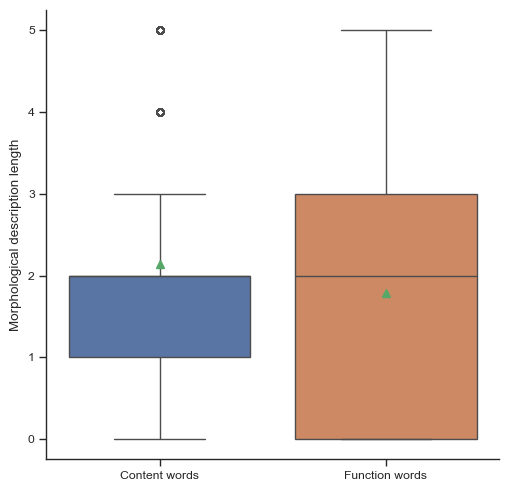

In [247]:
plt.figure(figsize=(10, 5))
sns.catplot(data=[cont_tags, func_tags], kind='box', showmeans=True)
plt.xticks([0, 1], ['Content words', 'Function words'])
plt.ylabel('Morphological description length')
sns.despine()
plt.show()

Let's look at Russian as well. Can you turn the code above into a function, so that we can easily apply it to other languages as well?

In [248]:
def count_features_by_word_class(text, nlp, content_tags, function_tags):
    '''
    Your function needs to take a text, a spacy model, and two lists of 
    POS tags (one for content words and one for function words) as input. 
    It should return two lists: one with the number of morphological features 
    for each content word in the text, and another with the number of 
    morphological features for each function word in the text.
    '''
    cont_tags = []
    func_tags = []

    for line in tqdm(text):
        for word_form in nlp(line):
            if word_form.pos_ in content_tags:
                cont_tags.append(len(word_form.morph))
            if word_form.pos_ in function_tags:
                func_tags.append(len(word_form.morph))

    return cont_tags, func_tags

Let's load the Russian bible and the model as we will need them later:

In [249]:
russian_bible = open('Russian.txt', 'r', encoding='utf-8').read().split('\n')
nlp_ru = spacy.load("ru_core_news_sm")

Let's count the number of features:

In [250]:
cont_tags_r, func_tags_r = count_features_by_word_class(russian_bible[:2000], 
                                                        nlp_ru, content_tags, function_tags)

  0%|          | 0/2000 [00:00<?, ?it/s]

Now let's plot the distribution:

<Figure size 1000x500 with 0 Axes>

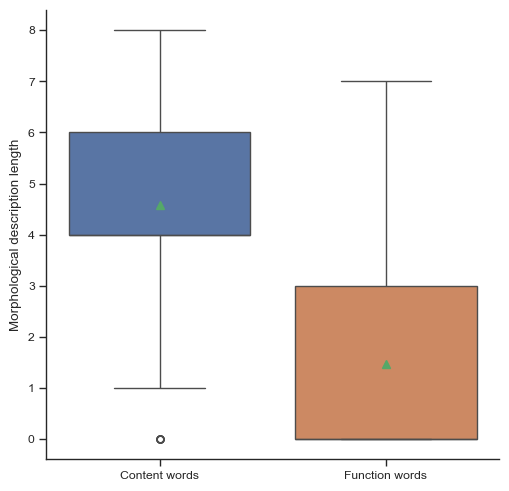

In [251]:
plt.figure(figsize=(10, 5))
sns.catplot(data=[cont_tags_r, func_tags_r], kind='box', showmeans=True)
plt.xticks([0, 1], ['Content words', 'Function words'])
plt.ylabel('Morphological description length')
sns.despine()
plt.show()

What does this tell us about the morphological complexity of function vs. content words in Russian? How does it compare to French?

## 3. Morphological features per word-form

Let's load the English bible and the model as we will need them later:

In [252]:
english_bible = open('English.txt', 'r', encoding='utf-8').read().split('\n')
nlp_en = spacy.load("en_core_web_sm")

Finally, we can use morphological features to approximate feature density: the number of annotated morphological features divided by the number of word-forms. This is a proxy for Greenberg's synthesis index, not a true morpheme-to-word ratio, because spaCy does not segment morphemes. Let's start with 100 sentences. 

In [253]:
num_morph = 0
num_tokens = 0

for sentence in english_bible[:1000]:
    doc = nlp_en(sentence)
    for token in doc:
        if token.is_alpha:
            num_morph += len(token.morph)
            num_tokens += 1

Let's see what we get:

In [254]:
print(f'Average number of morphological features per token in French: {num_morph / num_tokens}')

Average number of morphological features per token in French: 1.5039296710419705


How can we be sure that we are getting a stable estimate? Let's sample 100, 200, 500 and 1000 random sentences from the Bible and calculate the morphological features per token for each sample. We can then plot the estimates. 

You first need to write a function that does this counting procedure, and then apply it to the different samples.

In [255]:
def count_features_per_token(text, nlp):
    num_morph = 0
    num_tokens = 0

    for sentence in text:
        doc = nlp(sentence)
        for token in doc:
            if token.is_alpha:
                num_morph += len(token.morph)
                num_tokens += 1

    return num_morph / num_tokens

Now do the sampling, using random.sample function (and putting the results into the sample variable), and plot the estimates for each sample size. What do you notice?

In [256]:
ratios = []

for _ in range(5):  # Repeat 5 times
    ratio_sentences = []
    for size in tqdm([100, 200, 500, 1000]):
        sample = random.sample(english_bible, size)
        ratio_sentences.append(count_features_per_token(sample, nlp_en))
    ratios.append(ratio_sentences)

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

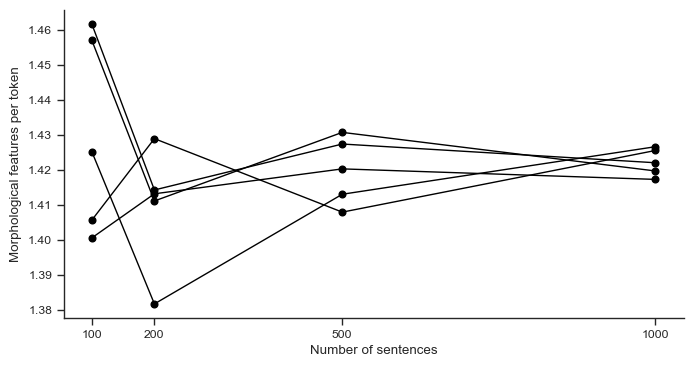

In [257]:
plt.figure(figsize=(8, 4))
for ratio in ratios:
    plt.plot([100, 200, 500, 1000], ratio, 
             marker='o', color='black', 
             linestyle='-', linewidth=1)
plt.xlabel('Number of sentences')
plt.ylabel('Morphological features per token')
plt.xticks([100, 200, 500, 1000])
sns.despine()
plt.show()

As we can see, the estimate is quite stable when 1000 sentences are sampled, so we can use such a small sample to estimate feature density. What happens when you sample 5000 sentences?

In [258]:
count_features_per_token(english_bible[:1000], nlp=nlp_en)

1.5039296710419705

It's pretty much the same as with 1000 sentences. So 1000 sentences should be enough to estimate morphological feature density in a language.

Let's compute this feature density for German now:

In [259]:
german_bible = open('German.txt', 'r', encoding='utf-8').read().split('\n')

nlp_de = spacy.load("de_core_news_sm")

The feature density for German:

In [260]:
german_bible_s = random.sample(german_bible, 1000)
count_features_per_token(german_bible_s, nlp_de)

2.781606101390758

Now, you can try the same thing for another language, like Russian. Does this number match its morphological type?

In [261]:
russian_bible = open('Russian.txt', 'r', encoding='utf-8').read().split('\n')
nlp_ru = spacy.load("ru_core_news_sm")

In [262]:
count_features_per_token(russian_bible[:1000], nlp_ru)

3.183560429821646

Let's compare all four languages. Sample 1000 sentences from each Bible four times and plot the estimates.


In [263]:
ratios = []

for _ in range(4):  # Repeat 4 times
    ratio_sentences = []
    for bible, nlp in zip([english_bible, french_bible, 
                           german_bible, russian_bible], 
                           [nlp_en, nlp_fr, 
                            nlp_de, nlp_ru]):
        ratio_sentences.append(count_features_per_token(random.sample(bible, 1000), nlp))
    ratios.append(ratio_sentences)

Let's plot the results for all four languages:

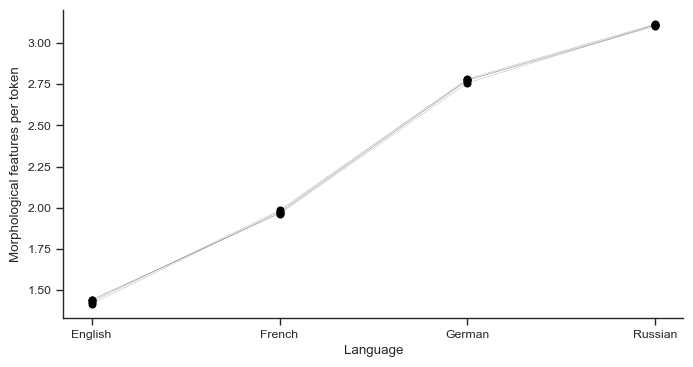

In [264]:
plt.figure(figsize=(8, 4))
for ratio in ratios:
    plt.plot(['English', 'French', 'German', 'Russian'], ratio, 
             marker='o', color='black', 
             linestyle='-', linewidth=0.1)
plt.xlabel('Language')
plt.ylabel('Morphological features per token')
sns.despine()
plt.show()

## 4. Similarity between morphological profiles

We looked at the morphological feature ratio for each language, but we can also look at the similarity between the morphological profiles of the four languages. We can use cosine similarity to measure the similarity between the morphological profiles of the four languages. 

For this, we would need to create a feature profile for each language, which is a vector of the percentage of word-forms carrying each annotated morphological feature. We can then compute the cosine similarity between these vectors to see how similar the morphological profiles of the languages are.

In [265]:
import pandas as pd
from collections import Counter

# get the bibles and models in a dictionary for easier access
bibles = {'English': english_bible, 'French': french_bible, 'German': german_bible, 'Russian': russian_bible}
models = {'English': nlp_en, 'French': nlp_fr, 'German': nlp_de, 'Russian': nlp_ru}


# sample 5000 sentences from the English Bible to use for all languages
sample_indices = random.sample(range(len(english_bible)), 2000)

def get_feature_profile(text, nlp, indices):
    '''
    Counts the number of morphological features in 
    the given text using the provided spaCy model. 
    It returns a Counter object with the counts of each morphological 
    feature and the total number of tokens processed.
    '''
    counts = Counter()
    token_count = 0
    for index in indices:
        for token in nlp(text[index]):
            if token.is_alpha:
                token_count += 1
                counts.update(token.morph.to_dict().keys())
    return counts, token_count

Let's get the vectors for each language.

In [266]:
profiles = {language: get_feature_profile(bibles[language], models[language], sample_indices) for language in bibles}
# only look at features that occur in at least one language
feature_names = sorted(set().union(*(counts for counts, _ in profiles.values())))
profile_table = pd.DataFrame({
    language: [100 * counts[feature] / token_count for feature in feature_names]
    for language, (counts, token_count) in profiles.items()
}, index=feature_names).T
# remove columns where all except one language have 0 values
profile_table = profile_table.loc[:, (profile_table != 0).any(axis=0)]

In [267]:
profile_table.head(10).round(2)

,Animacy,Aspect,Case,ConjType,Definite,Degree,Foreign,Gender,Mood,NumType,...,Person,Polarity,Poss,PronType,Reflex,StyleVariant,Tense,VerbForm,VerbType,Voice
English,0.00,2.57,7.06,7.49,9.27,3.39,0.00,4.38,2.80,0.99,...,11.53,0.86,3.33,22.01,0.14,0.00,10.77,16.41,1.18,0.0
French,0.00,0.00,0.00,0.00,12.36,0.00,0.00,42.22,9.42,0.86,...,17.02,1.75,3.11,16.68,0.73,0.00,13.49,15.17,0.00,0.9
German,0.00,0.00,52.96,0.00,9.37,3.78,0.05,44.69,13.96,0.00,...,23.41,0.00,3.34,27.17,0.68,0.00,13.62,18.67,0.00,0.0
Russian,34.77,17.60,53.36,0.00,0.00,7.14,0.00,48.49,13.95,0.00,...,15.54,2.00,0.00,0.00,0.00,1.16,14.89,17.60,0.00,17.6


Each row is now a language profile. 

In [268]:
vectors = profile_table.to_numpy()

In [269]:
vectors[0].round(1)

array([ 0. ,  2.6,  7.1,  7.5,  9.3,  3.4,  0. ,  4.4,  2.8,  1. , 36.8,
       11.5,  0.9,  3.3, 22. ,  0.1,  0. , 10.8, 16.4,  1.2,  0. ])

Calculate pairwise cosine similarity; a value closer to 1 means that two languages have more similar distributions of annotated morphological features. Use sklearn's `cosine_similarity` function to calculate the similarity between the language profiles.

In [270]:
import sklearn 

sm = sklearn.metrics.pairwise.cosine_similarity(vectors)

In [271]:
sm

array([[1.        , 0.84743799, 0.8253368 , 0.66182741],
       [0.84743799, 1.        , 0.85965387, 0.76293915],
       [0.8253368 , 0.85965387, 1.        , 0.88520455],
       [0.66182741, 0.76293915, 0.88520455, 1.        ]])

Plot the cosine similarity matrix as a heatmap. What do you notice about the similarity between the languages?

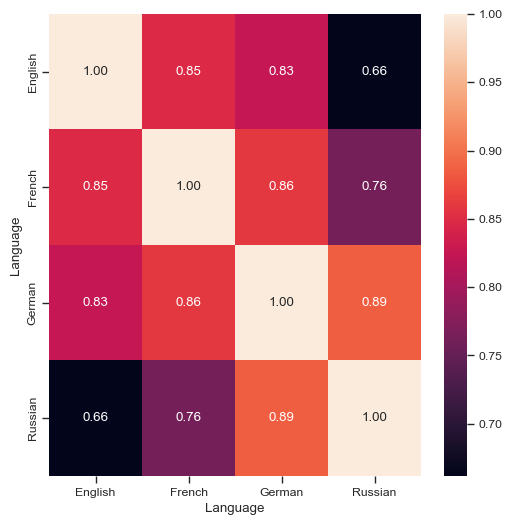

In [273]:
plt.figure(figsize=(6, 6))
sns.heatmap(
    sm,
    annot=True,
    fmt=".2f",
    xticklabels=models.keys(),
    yticklabels=models.keys()
)
plt.xlabel("Language")
plt.ylabel("Language")
plt.show()